[INFO] patients day 0: TP=36, FP=62, TN=1, FN=1, TPR=0.973 FPR=0.984 ACC=0.370 CE=0.879
[INFO] patients day 20: TP=30, FP=10, TN=54, FN=6, TPR=0.833 FPR=0.156 ACC=0.840 CE=0.410
[INFO] patients day 40: TP=31, FP=16, TN=48, FN=5, TPR=0.861 FPR=0.250 ACC=0.790 CE=0.459
[INFO] patients day 60: TP=28, FP=17, TN=47, FN=7, TPR=0.800 FPR=0.266 ACC=0.758 CE=0.503
[INFO] patients day 80: TP=27, FP=18, TN=53, FN=2, TPR=0.931 FPR=0.254 ACC=0.800 CE=0.482
[INFO] patients day 100: TP=28, FP=14, TN=56, FN=2, TPR=0.933 FPR=0.200 ACC=0.840 CE=0.393
[INFO] patients day 120: TP=25, FP=13, TN=57, FN=5, TPR=0.833 FPR=0.186 ACC=0.820 CE=0.433
[INFO] caregivers day 0: TP=52, FP=47, TN=0, FN=1, TPR=0.981 FPR=1.000 ACC=0.520 CE=0.787
[INFO] caregivers day 20: TP=50, FP=19, TN=24, FN=7, TPR=0.877 FPR=0.442 ACC=0.740 CE=0.554
[INFO] caregivers day 40: TP=59, FP=9, TN=30, FN=2, TPR=0.967 FPR=0.231 ACC=0.890 CE=0.328
[INFO] caregivers day 60: TP=45, FP=18, TN=33, FN=3, TPR=0.938 FPR=0.353 ACC=0.788 CE=0.483
[INFO

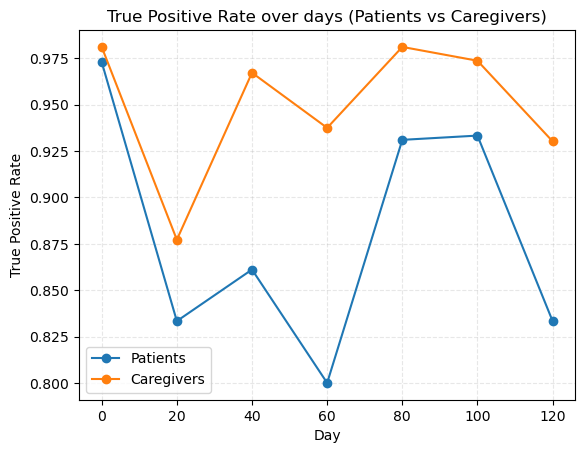

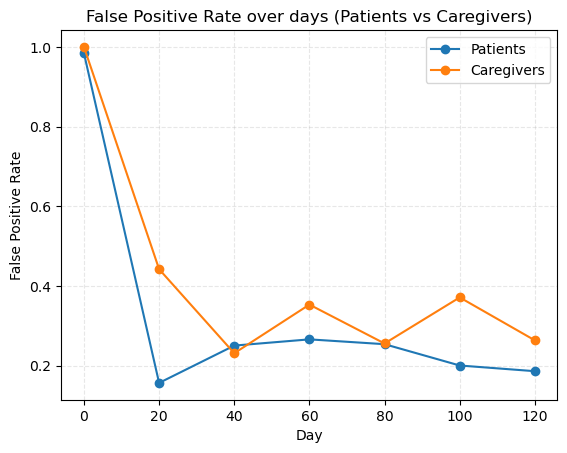

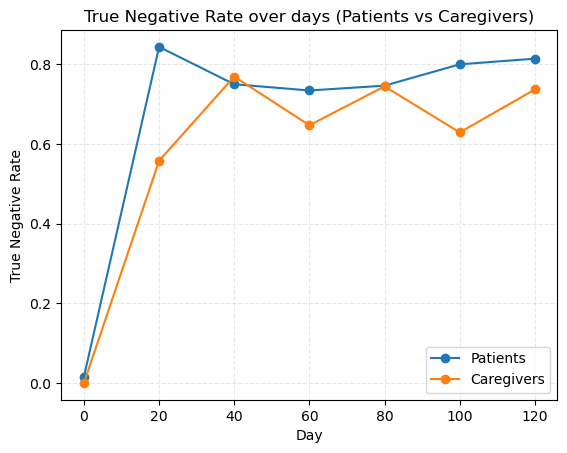

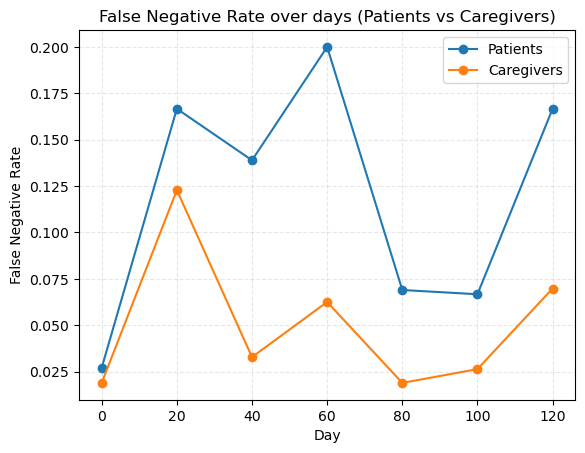

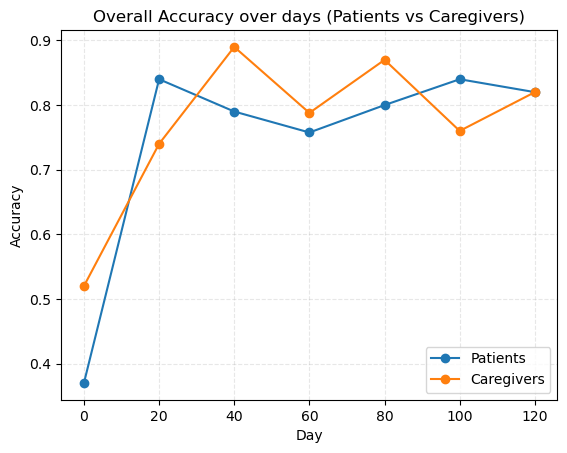

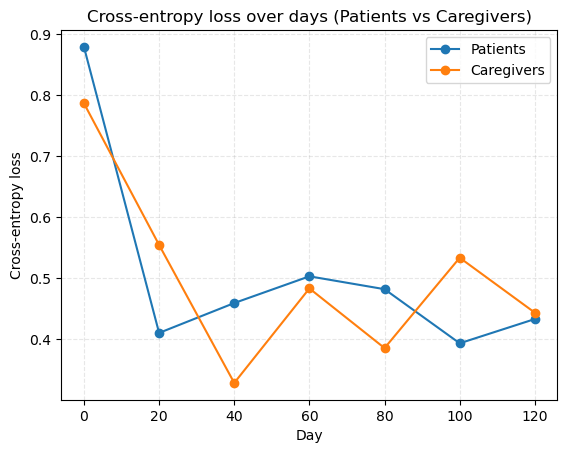

In [ ]:
# %%
import json
from pathlib import Path
from typing import Dict, Any, Optional

import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Config
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
PREDICTIONS_DIR = Path("predictions")

ROLES = ["patients", "caregivers"]
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants_demographics.json
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_demographics.json must be a dict keyed by participant ID.")

# --------------------
# Helper: get ground-truth label for (pid, day)
# actual: 1 = completed (Yes), 0 = missing (No)
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        # treat as missing -> No
        return 0

    val = mood_map[key]
    # explicitly treat "Missing" as no completion
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    # any numeric / non-missing value → Yes
    return 1

# --------------------
# Helper: safely extract decision (Yes/No -> 1/0) and confidence from parsed json
# --------------------
def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):  # "Yes"
        y_hat = 1
    elif dec_str.startswith("n"):  # "No"
        y_hat = 0
    else:
        # unknown label, skip
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        # if no valid confidence, set to 0.5 as neutral
        conf = 0.5

    # clamp between (0,1) for safety
    conf = max(1e-6, min(1.0 - 1e-6, conf))

    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Aggregate metrics storage
# metrics[role][metric_name] = list over DAYS
# --------------------
metrics = {
    role: {
        "tpr": [],
        "fpr": [],
        "tnr": [],
        "fnr": [],
        "acc": [],
        "ce":  [],
    }
    for role in ROLES
}

# --------------------
# Main loop: per role × day, compute metrics
# --------------------
for role in ROLES:
    for day in DAYS:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            print(f"[WARN] Missing predictions file: {pred_file}. Metrics will be NaN for {role}, day {day}.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            print(f"[WARN] Predictions file {pred_file} is not a dict. Metrics will be NaN.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            continue

        # Counters
        TP = FP = TN = FN = 0
        ce_losses = []  # list of cross-entropy losses for each participant with valid conf/label

        for pid, rec in preds_dict.items():
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                # try to parse raw_output as fallback
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue  # skip if still not valid

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]        # prediction: 1 = Yes, 0 = No
            conf  = info["confidence"]   # p(decision is correct)

            # ground truth
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Update confusion matrix
            if y_true == 1 and y_hat == 1:
                TP += 1
            elif y_true == 0 and y_hat == 1:
                FP += 1
            elif y_true == 0 and y_hat == 0:
                TN += 1
            elif y_true == 1 and y_hat == 0:
                FN += 1

            # Convert "confidence decision is correct" into probability that label = 1 (Yes)
            # If decision == Yes → p_yes = conf
            # If decision == No  → p_yes = 1 - conf
            if y_hat == 1:
                p_yes = conf
            else:
                p_yes = 1.0 - conf

            # clamp to avoid log(0)
            p_yes = max(1e-6, min(1.0 - 1e-6, p_yes))
            # standard cross-entropy for binary classification
            ce = -(y_true * np.log(p_yes) + (1 - y_true) * np.log(1 - p_yes))
            ce_losses.append(ce)

        # Compute rates
        P = TP + FN  # actual positives
        N = TN + FP  # actual negatives
        total = P + N

        # TPR = TP / P (if P>0)
        tpr = TP / P if P > 0 else np.nan
        # FPR = FP / N
        fpr = FP / N if N > 0 else np.nan
        # TNR = TN / N
        tnr = TN / N if N > 0 else np.nan
        # FNR = FN / P
        fnr = FN / P if P > 0 else np.nan
        # Accuracy
        acc = (TP + TN) / total if total > 0 else np.nan
        # Cross-entropy: mean over participants with valid confidence
        ce_mean = float(np.mean(ce_losses)) if ce_losses else np.nan

        metrics[role]["tpr"].append(tpr)
        metrics[role]["fpr"].append(fpr)
        metrics[role]["tnr"].append(tnr)
        metrics[role]["fnr"].append(fnr)
        metrics[role]["acc"].append(acc)
        metrics[role]["ce"].append(ce_mean)

        print(f"[INFO] {role} day {day}: "
              f"TP={TP}, FP={FP}, TN={TN}, FN={FN}, "
              f"TPR={tpr:.3f} FPR={fpr:.3f} ACC={acc:.3f} CE={ce_mean:.3f}")

# --------------------
# Plotting helpers
# --------------------
def plot_metric(metric_name: str, ylabel: str, title: str):
    plt.figure()
    for role in ROLES:
        plt.plot(DAYS, metrics[role][metric_name], marker="o", label=role.capitalize())
    plt.xlabel("Day")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.show()

# 1. TPR
plot_metric("tpr",
            ylabel="True Positive Rate",
            title="True Positive Rate over days (Patients vs Caregivers)")

# 2. FPR
plot_metric("fpr",
            ylabel="False Positive Rate",
            title="False Positive Rate over days (Patients vs Caregivers)")

# 3. TNR
plot_metric("tnr",
            ylabel="True Negative Rate",
            title="True Negative Rate over days (Patients vs Caregivers)")

# 4. FNR
plot_metric("fnr",
            ylabel="False Negative Rate",
            title="False Negative Rate over days (Patients vs Caregivers)")

# 5. Accuracy
plot_metric("acc",
            ylabel="Accuracy",
            title="Overall Accuracy over days (Patients vs Caregivers)")

# 6. Cross entropy loss
plot_metric("ce",
            ylabel="Cross-entropy loss",
            title="Cross-entropy loss over days (Patients vs Caregivers)")


[INFO] patients day 0: TP=19, FP=41, TN=1, FN=0, TPR=1.000 FPR=0.976 ACC=0.328 CE=1.055
[INFO] patients day 20: TP=31, FP=10, TN=54, FN=5, TPR=0.861 FPR=0.156 ACC=0.850 CE=0.405
[INFO] patients day 40: TP=33, FP=16, TN=48, FN=3, TPR=0.917 FPR=0.250 ACC=0.810 CE=0.450
[INFO] patients day 60: TP=29, FP=18, TN=46, FN=7, TPR=0.806 FPR=0.281 ACC=0.750 CE=0.490
[INFO] patients day 80: TP=28, FP=20, TN=51, FN=1, TPR=0.966 FPR=0.282 ACC=0.790 CE=0.479
[INFO] patients day 100: TP=29, FP=14, TN=56, FN=1, TPR=0.967 FPR=0.200 ACC=0.850 CE=0.407
[INFO] patients day 120: TP=25, FP=11, TN=58, FN=5, TPR=0.833 FPR=0.159 ACC=0.838 CE=0.428
[INFO] caregivers day 0: TP=52, FP=46, TN=1, FN=1, TPR=0.981 FPR=0.979 ACC=0.530 CE=0.861
[INFO] caregivers day 20: TP=50, FP=17, TN=26, FN=7, TPR=0.877 FPR=0.395 ACC=0.760 CE=0.540
[INFO] caregivers day 40: TP=59, FP=8, TN=31, FN=2, TPR=0.967 FPR=0.205 ACC=0.900 CE=0.324
[INFO] caregivers day 60: TP=43, FP=20, TN=32, FN=5, TPR=0.896 FPR=0.385 ACC=0.750 CE=0.494
[INFO

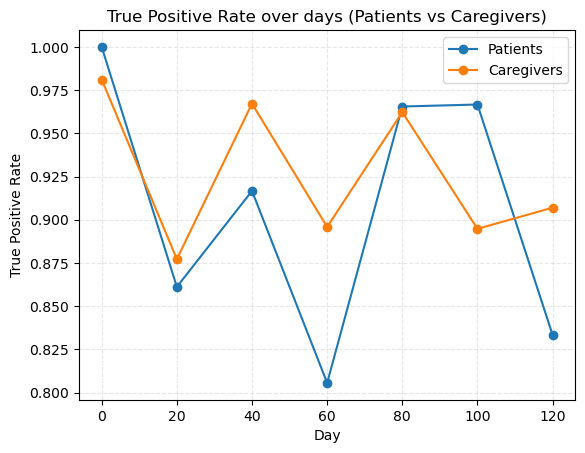

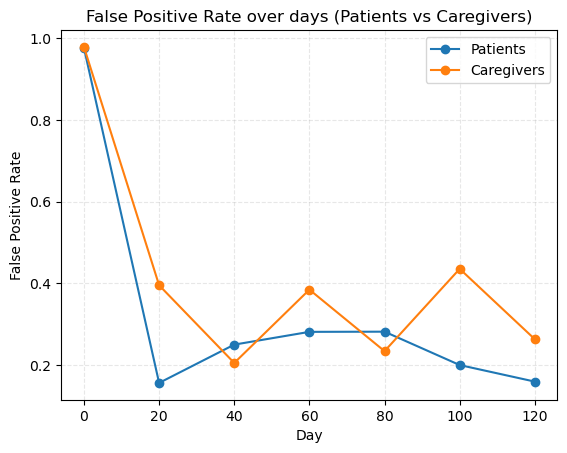

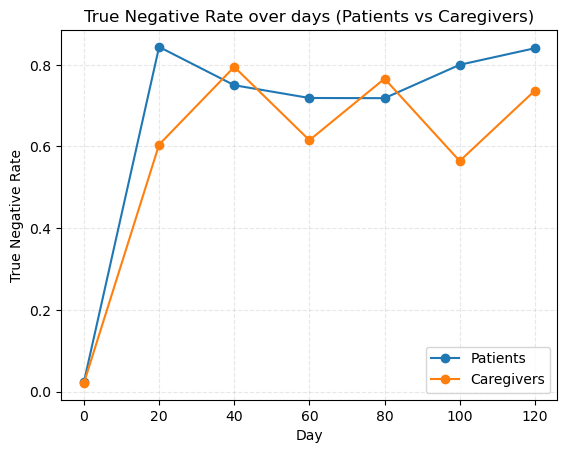

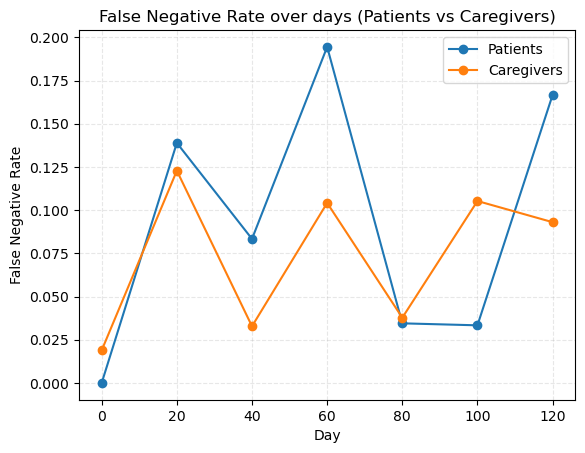

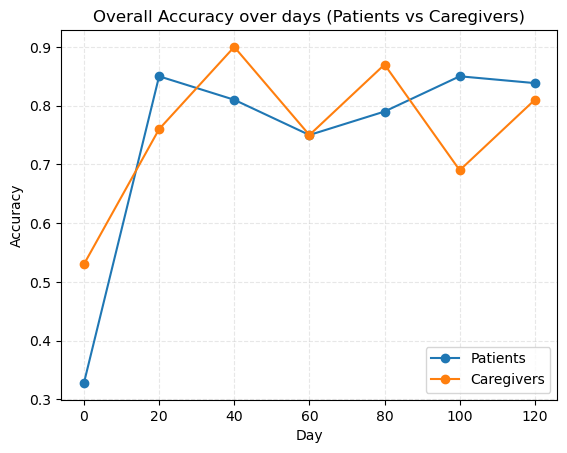

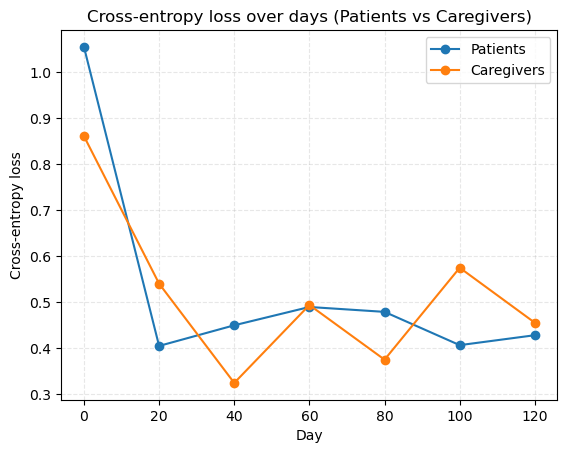

In [6]:
# %%
import json
from pathlib import Path
from typing import Dict, Any, Optional

import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Config
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
PREDICTIONS_DIR = Path("predictions3")

ROLES = ["patients", "caregivers"]
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants_demographics.json
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_demographics.json must be a dict keyed by participant ID.")

# --------------------
# Helper: get ground-truth label for (pid, day)
# actual: 1 = completed (Yes), 0 = missing (No)
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        # treat as missing -> No
        return 0

    val = mood_map[key]
    # explicitly treat "Missing" as no completion
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    # any numeric / non-missing value → Yes
    return 1

# --------------------
# Helper: safely extract decision (Yes/No -> 1/0) and confidence from parsed json
# --------------------
def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):  # "Yes"
        y_hat = 1
    elif dec_str.startswith("n"):  # "No"
        y_hat = 0
    else:
        # unknown label, skip
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        # if no valid confidence, set to 0.5 as neutral
        conf = 0.5

    # clamp between (0,1) for safety
    conf = max(1e-6, min(1.0 - 1e-6, conf))

    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Aggregate metrics storage
# metrics[role][metric_name] = list over DAYS
# --------------------
metrics = {
    role: {
        "tpr": [],
        "fpr": [],
        "tnr": [],
        "fnr": [],
        "acc": [],
        "ce":  [],
    }
    for role in ROLES
}

# --------------------
# Main loop: per role × day, compute metrics
# --------------------
for role in ROLES:
    for day in DAYS:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            print(f"[WARN] Missing predictions file: {pred_file}. Metrics will be NaN for {role}, day {day}.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            print(f"[WARN] Predictions file {pred_file} is not a dict. Metrics will be NaN.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            continue

        # Counters
        TP = FP = TN = FN = 0
        ce_losses = []  # list of cross-entropy losses for each participant with valid conf/label

        for pid, rec in preds_dict.items():
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                # try to parse raw_output as fallback
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue  # skip if still not valid

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]        # prediction: 1 = Yes, 0 = No
            conf  = info["confidence"]   # p(decision is correct)

            # ground truth
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Update confusion matrix
            if y_true == 1 and y_hat == 1:
                TP += 1
            elif y_true == 0 and y_hat == 1:
                FP += 1
            elif y_true == 0 and y_hat == 0:
                TN += 1
            elif y_true == 1 and y_hat == 0:
                FN += 1

            # Convert "confidence decision is correct" into probability that label = 1 (Yes)
            # If decision == Yes → p_yes = conf
            # If decision == No  → p_yes = 1 - conf
            if y_hat == 1:
                p_yes = conf
            else:
                p_yes = 1.0 - conf

            # clamp to avoid log(0)
            p_yes = max(1e-6, min(1.0 - 1e-6, p_yes))
            # standard cross-entropy for binary classification
            ce = -(y_true * np.log(p_yes) + (1 - y_true) * np.log(1 - p_yes))
            ce_losses.append(ce)

        # Compute rates
        P = TP + FN  # actual positives
        N = TN + FP  # actual negatives
        total = P + N

        # TPR = TP / P (if P>0)
        tpr = TP / P if P > 0 else np.nan
        # FPR = FP / N
        fpr = FP / N if N > 0 else np.nan
        # TNR = TN / N
        tnr = TN / N if N > 0 else np.nan
        # FNR = FN / P
        fnr = FN / P if P > 0 else np.nan
        # Accuracy
        acc = (TP + TN) / total if total > 0 else np.nan
        # Cross-entropy: mean over participants with valid confidence
        ce_mean = float(np.mean(ce_losses)) if ce_losses else np.nan

        metrics[role]["tpr"].append(tpr)
        metrics[role]["fpr"].append(fpr)
        metrics[role]["tnr"].append(tnr)
        metrics[role]["fnr"].append(fnr)
        metrics[role]["acc"].append(acc)
        metrics[role]["ce"].append(ce_mean)

        print(f"[INFO] {role} day {day}: "
              f"TP={TP}, FP={FP}, TN={TN}, FN={FN}, "
              f"TPR={tpr:.3f} FPR={fpr:.3f} ACC={acc:.3f} CE={ce_mean:.3f}")

# --------------------
# Plotting helpers
# --------------------
def plot_metric(metric_name: str, ylabel: str, title: str):
    plt.figure()
    for role in ROLES:
        plt.plot(DAYS, metrics[role][metric_name], marker="o", label=role.capitalize())
    plt.xlabel("Day")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.show()

# 1. TPR
plot_metric("tpr",
            ylabel="True Positive Rate",
            title="True Positive Rate over days (Patients vs Caregivers)")

# 2. FPR
plot_metric("fpr",
            ylabel="False Positive Rate",
            title="False Positive Rate over days (Patients vs Caregivers)")

# 3. TNR
plot_metric("tnr",
            ylabel="True Negative Rate",
            title="True Negative Rate over days (Patients vs Caregivers)")

# 4. FNR
plot_metric("fnr",
            ylabel="False Negative Rate",
            title="False Negative Rate over days (Patients vs Caregivers)")

# 5. Accuracy
plot_metric("acc",
            ylabel="Accuracy",
            title="Overall Accuracy over days (Patients vs Caregivers)")

# 6. Cross entropy loss
plot_metric("ce",
            ylabel="Cross-entropy loss",
            title="Cross-entropy loss over days (Patients vs Caregivers)")

In [2]:
# Print the prompt for participant P094 from prompts/patients_day20.json

import json
from pathlib import Path
import sys

PROMPTS_PATH = Path("prompts3/patients_day40.json")
TARGET_PID = "P117"

if not PROMPTS_PATH.exists():
    sys.exit(f"[ERROR] File not found: {PROMPTS_PATH.resolve()}")

with PROMPTS_PATH.open("r", encoding="utf-8") as f:
    prompts = json.load(f)

if not isinstance(prompts, dict):
    sys.exit("[ERROR] JSON is not a dict of {participant_id: prompt_str}")

prompt = prompts.get(TARGET_PID)
if prompt is None:
    # Helpful diagnostics if the exact ID isn't present
    # Try to suggest close matches by prefix
    close = [k for k in prompts.keys() if k.startswith(TARGET_PID[:3])]
    msg = f"[ERROR] Participant ID '{TARGET_PID}' not found in {PROMPTS_PATH.name}."
    if close:
        msg += f"\n[HINT] IDs with similar prefix: {sorted(close)[:10]}"
    sys.exit(msg)

print(prompt)

You are a patient participant in a dyad in the ROADMAP 2.0 mobile-health study. 

You are a patient recovering from a hematopoietic cell transplantation (HCT) to treat a blood-related disease such as leukemia or lymphoma. During recovery, you may experience fatigue, nausea, pain, sleep disturbances, and emotional stress, while relying on your care partner and medical team to help you regain strength and prevent complications like infections or graft-versus-host disease. 

Each day, you are asked to enter your mood on a 1-10 scale (1=worst, 10=best). 

The study seeks to understand links between sensor data and well-being and to support caregivers during and after transplant. 

Each time step in this simulation represents one day.

Below is your background and history with the program. Based on this information, decide whether you will complete today's mood survey.

- **Your Background:**
- You are in the 61+ age group.
- Your gender is female.
- Your monthly income is $3,000 - $4,999.


In [1]:
import json
from pathlib import Path
import sys

PROMPTS_PATH = Path("prompts3/caregivers_day60.json")
TARGET_PID = "P210"

if not PROMPTS_PATH.exists():
    sys.exit(f"[ERROR] File not found: {PROMPTS_PATH.resolve()}")

with PROMPTS_PATH.open("r", encoding="utf-8") as f:
    prompts = json.load(f)

if not isinstance(prompts, dict):
    sys.exit("[ERROR] JSON is not a dict of {participant_id: prompt_str}")

prompt = prompts.get(TARGET_PID)
if prompt is None:
    # Helpful diagnostics if the exact ID isn't present
    # Try to suggest close matches by prefix
    close = [k for k in prompts.keys() if k.startswith(TARGET_PID[:3])]
    msg = f"[ERROR] Participant ID '{TARGET_PID}' not found in {PROMPTS_PATH.name}."
    if close:
        msg += f"\n[HINT] IDs with similar prefix: {sorted(close)[:10]}"
    sys.exit(msg)

print(prompt)

You are a caregiver participant in a dyad in the ROADMAP 2.0 mobile-health study. 

You are a caregiver for a loved one recovering from a hematopoietic cell transplantation (HCT) for a serious blood or immune disorder. You provide daily physical and emotional support, monitor for complications, manage medications and appointments, and balance these duties with your own daily work routine. 

Each day, you are asked to enter your mood on a 1-10 scale (1=worst, 10=best). 

The study seeks to understand links between sensor data and well-being and to support caregivers during and after transplant. 

Each time step in this simulation represents one day.

Below is your background and history with the program. Based on this information, decide whether you will complete today's mood survey.

- **Your Background:**
- You are in the 61+ age group.
- Your gender is female.
- Your monthly income is Less than $1,000.
- You provide caregiving to your patient for Less than or equal to 40 hours per we